# Does the annotation truncation change any of our conclusions?

**A sensitivity analysis of the scoring, not a correction to it.**

## The defect

The NIfTI masks in this dataset are **truncated in z**: labelling stops at a slice where
the anatomy plainly continues. On those slices the ground truth reads "background
everywhere", so a prediction that is anatomically correct is scored as a false positive,
and the model is rewarded for reproducing *where the annotator stopped drawing* rather
than the anatomy. §1 measures how widespread this is, using the label files alone.

This distorts results in two different ways, and the second is the dangerous one:

1. **It deflates every absolute score.** Reported Dice mixes segmentation quality with
   extent-guessing.
2. **It biases comparisons between arms, non-uniformly.** Whichever arm happens to be
   more conservative near the ends of a volume collects real Dice for it. That is not a
   constant offset you can subtract — it means part of an arm *ranking* is a ranking of
   protocol-mimicry. We already know this is not hypothetical: on `CADRE_1851` the
   deficit lying outside the labelled region falls 0.077 → 0.046 → 0.025 across the
   baseline, augmented and 2.5D-context arms.

## What a sensitivity analysis is

Re-score under a second defensible assumption and check whether the **conclusions** move.
Report both, side by side.

- Conclusions unchanged → they are robust to the assumption, and you can say so.
- Conclusions change → the finding was partly an artifact of the scoring convention. That
  is itself the result, and it must be reported.

It is **not** a licence to pick whichever number looks better. The primary endpoint stays
pre-specified and unchanged; this runs alongside it.

## The three policies

| policy | slices scored | what it asks |
|---|---|---|
| `full` | every slice | **the primary, unchanged.** Recomputed here only as an integrity check |
| `annotated` | slices carrying any annotation | given the region actually labelled, how good is the model? |
| `eroded` | `annotated`, shrunk 3 slices at each end | is `annotated` itself sensitive to where the boundary is drawn? |

`eroded` exists because the outermost labelled slice is often only *partially* drawn —
the annotator tapering off rather than stopping cleanly. If `annotated` and `eroded`
agree, the answer does not depend on exactly where the line is placed.

## Scope

Produced by `rescore_annotated_extent.py`, which **re-scores existing `best.pth`
checkpoints**. Nothing is retrained, no configuration changed, and only **validation**
patients are read — the held-out test set is never touched. The `full` policy reproduces
the Dice already recorded by `train.py` to <5e-3 per (patient, class), which is the
integrity check that this notebook scores the same way training did.

In [1]:
import csv, glob, json, os
from pathlib import Path
from collections import defaultdict

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon, t as student_t

from utils import metrics

# --- what we are comparing ---------------------------------------------------
ARMS = {                                    # label -> run-name prefix
    'baseline':  'both_baseline_dice_ce',   # augment=False, context_slices=0
    'aug':       'both_data_aug_dice_ce',   # augment=True,  context_slices=0  <- control
    'cs1':       'both_ctx_cs1',
    'cs2':       'both_ctx_cs2',
    'cs3':       'both_ctx_cs3',
    'attn':      'both_attn',               # arch=attention_unet
}
VARIANTS = ['full', 'annotated', 'eroded']
CLASSES  = ['LV', 'RV', 'LA', 'RA', 'EAT', 'all_classes_macro']
EAT      = 'EAT'

# --- plot style: same validated reference palette as the other notebooks -----
C_BLUE, C_ORANGE, C_AQUA, C_YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
C_MAGENTA, C_GREEN, C_VIOLET, C_RED = '#e87ba4', '#008300', '#4a3aa7', '#e34948'
SURFACE, INK, INK_2, INK_MUTED = '#fcfcfb', '#0b0b0b', '#52514e', '#8a8880'
BLUE_200, BLUE_450, BLUE_650 = '#9ec5f4', '#2a78d6', '#104281'

# categorical slots, assigned in fixed order and never cycled
VARIANT_COLOR = {'full': C_BLUE, 'annotated': C_ORANGE, 'eroded': C_AQUA}
ARM_COLOR = dict(zip(ARMS, [C_BLUE, C_ORANGE, C_AQUA, C_YELLOW, C_MAGENTA, C_GREEN]))

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': INK_MUTED, 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': INK_2, 'axes.titlecolor': INK, 'axes.titlesize': 10.5,
    'axes.titleweight': 'semibold', 'axes.titlelocation': 'left', 'axes.titlepad': 18,
    'text.color': INK, 'xtick.color': INK_2, 'ytick.color': INK_2,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'axes.labelsize': 9.5,
    'grid.color': '#e6e5e1', 'grid.linewidth': 0.7, 'axes.grid': True, 'axes.axisbelow': True,
    'legend.frameon': False, 'legend.fontsize': 9, 'font.size': 10,
    'lines.linewidth': 2.0, 'figure.dpi': 110,
})

def subtitle(ax, text):
    ax.text(0.0, 1.004, text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=8.5, color=INK_2)

REPO = Path.cwd()
assert (REPO / 'train.py').exists(), f'run this notebook from the repo root, not {REPO}'
print('arms:', list(ARMS), '\npolicies:', VARIANTS)

/hpc/jgeo610/Virtual_ENV/unet_env/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


arms: ['baseline', 'aug', 'cs1', 'cs2', 'cs3', 'attn'] 
policies: ['full', 'annotated', 'eroded']


## 1. The defect, measured on the label files alone

No model is involved in this section. It reads the NIfTI masks directly and asks a single
question of each volume: **which slices were drawn on at all?**

A slice counts as annotated if *any* foreground class is present. The union over classes
is the right test — one structure can legitimately be absent from a slice inside the
heart, but a slice where *every* structure is absent was never drawn on.

Two numbers per volume:

- **unannotated fraction** — how much of the volume falls outside the annotated block.
  This is prevalence.
- **boundary severity** — foreground voxels on the outermost *labelled* slice, as a share
  of that volume's peak. Near 0 means the annotation tapered out naturally where the
  anatomy ended. Near 1 means it **stopped mid-structure**, which is the case that
  actively penalises a correct prediction.

In [2]:
# --- census of the annotated extent, straight from the masks -----------------
census = []
for f in sorted(glob.glob('data/masks/*.nii*')):
    pid = os.path.basename(f).split('.')[0]
    m = np.asanyarray(nib.load(f).dataobj).transpose(2, 0, 1)   # -> (z, y, x)
    fg = (m > 0).reshape(m.shape[0], -1).sum(1)
    keep = metrics.annotated_slices(m)
    z = np.flatnonzero(keep)
    peak = fg.max()
    census.append(dict(
        patient_id=pid, n_slices=m.shape[0], n_annotated=int(keep.sum()),
        lo=int(z[0]), hi=int(z[-1]),
        interior_blank=int((z[-1] - z[0] + 1) - keep.sum()),
        unannotated_frac=1 - keep.sum() / m.shape[0],
        sev_top=fg[z[-1]] / peak, sev_bot=fg[z[0]] / peak,
        fg_profile=fg / peak,
    ))

n = len(census)
uf = np.array([c['unannotated_frac'] for c in census])
st = np.array([c['sev_top'] for c in census])
sb = np.array([c['sev_bot'] for c in census])

print(f'{n} volumes\n')
print(f'  volumes with ANY unannotated slice        {sum(c["n_annotated"] < c["n_slices"] for c in census)}/{n}')
print(f'  unannotated fraction   mean {uf.mean():.1%}   median {np.median(uf):.1%}   max {uf.max():.1%}')
print(f'  volumes losing >20% of slices             {(uf > 0.20).sum()}/{n}')
print(f'\n  severity -- annotation stops mid-structure (boundary fg > 30% of peak):')
print(f'    at the TOP end     {(st > 0.30).sum()}/{n}   worst {st.max():.0%}  '
      f'({census[int(np.argmax(st))]["patient_id"]})')
print(f'    at the BOTTOM end  {(sb > 0.30).sum()}/{n}   worst {sb.max():.0%}  '
      f'({census[int(np.argmax(sb))]["patient_id"]})')
gaps = [c for c in census if c['interior_blank']]
print(f'\n  volumes with blank slices INSIDE the annotated block: '
      f'{len(gaps)} ' + (f'({gaps[0]["patient_id"]}, {gaps[0]["interior_blank"]} slices)' if gaps else ''))
print('    -- which is why the policy uses a per-slice mask, not a (lo, hi) range')

50 volumes

  volumes with ANY unannotated slice        49/50
  unannotated fraction   mean 16.6%   median 16.5%   max 34.0%
  volumes losing >20% of slices             17/50

  severity -- annotation stops mid-structure (boundary fg > 30% of peak):
    at the TOP end     4/50   worst 43%  (CADRE_1851)
    at the BOTTOM end  26/50   worst 99%  (CADRE_1855)

  volumes with blank slices INSIDE the annotated block: 1 (CADRE_1866, 7 slices)
    -- which is why the policy uses a per-slice mask, not a (lo, hi) range


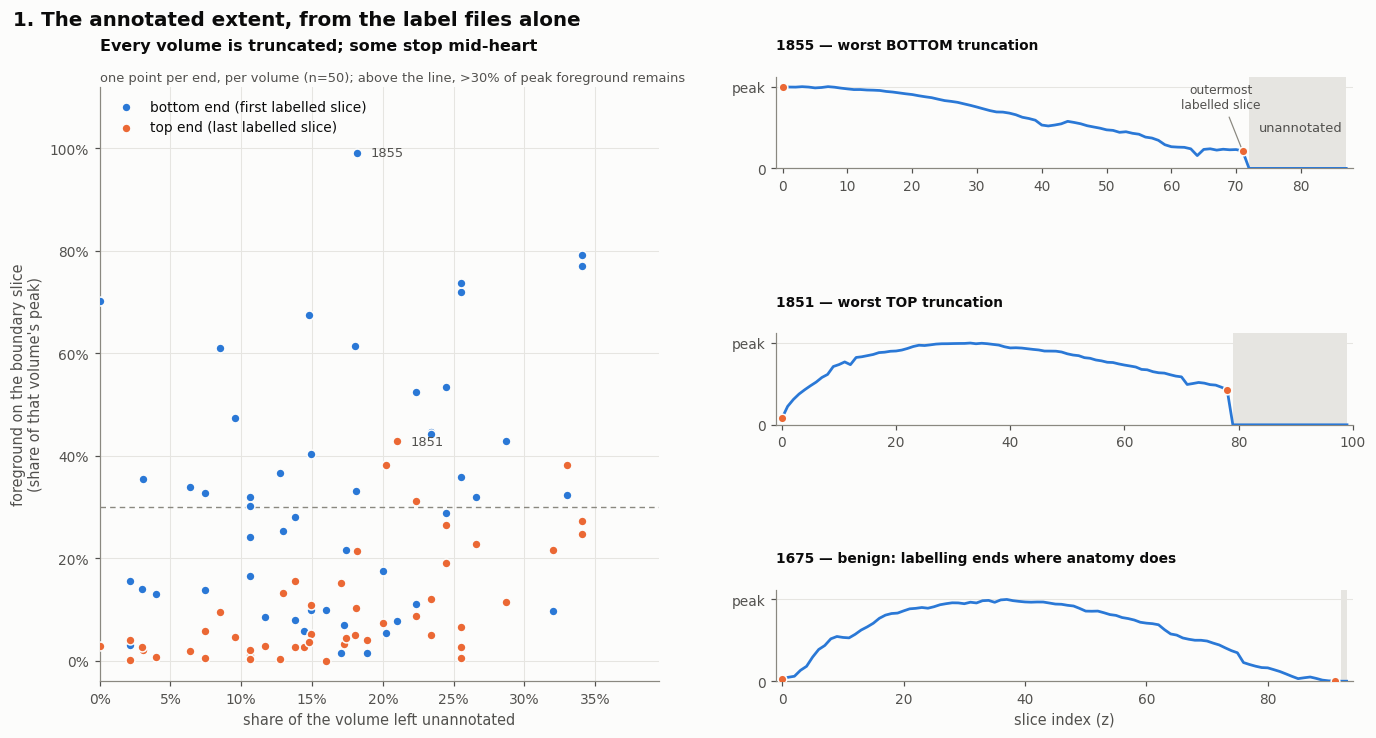

In [3]:
fig = plt.figure(figsize=(12.4, 6.6), layout='constrained')
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.15])

# (a) prevalence vs severity -- one point per END, per volume
ax = fig.add_subplot(gs[0, 0])
ax.axhline(0.30, color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 3)), zorder=1)
ax.scatter(uf, sb, s=34, color=C_BLUE, edgecolor=SURFACE, linewidth=1.0,
           label='bottom end (first labelled slice)', zorder=3)
ax.scatter(uf, st, s=34, color=C_ORANGE, edgecolor=SURFACE, linewidth=1.0,
           label='top end (last labelled slice)', zorder=3)
for idx, yv in ((int(np.argmax(sb)), sb[int(np.argmax(sb))]),
                (int(np.argmax(st)), st[int(np.argmax(st))])):
    ax.annotate(census[idx]['patient_id'].replace('CADRE_', ''), (uf[idx], yv),
                textcoords='offset points', xytext=(9, 0), fontsize=8.5,
                color=INK_2, va='center')
ax.set_xlabel('share of the volume left unannotated')
ax.set_ylabel("foreground on the boundary slice\n(share of that volume's peak)")
ax.set_xlim(0, max(uf) * 1.16); ax.set_ylim(-0.04, 1.12)
ax.xaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.set_title('Every volume is truncated; some stop mid-heart', pad=24)
subtitle(ax, f'one point per end, per volume (n={n}); above the line, '
             f'>30% of peak foreground remains')
ax.legend(loc='upper left', ncol=1)

# (b) the mechanism -- worst bottom, worst top, and a benign volume for contrast
picks = [(census[int(np.argmax(sb))], 'worst BOTTOM truncation'),
         (census[int(np.argmax(st))], 'worst TOP truncation'),
         (census[int(np.argmin(np.maximum(st, sb)))], 'benign: labelling ends where anatomy does')]
sub = gs[0, 1].subgridspec(3, 1, hspace=0.42)
for k, (c, why) in enumerate(picks):
    ax = fig.add_subplot(sub[k, 0])
    p, z = c['fg_profile'], np.arange(len(c['fg_profile']))
    unann = ~metrics.annotated_slices(
        np.asanyarray(nib.load(glob.glob(f"data/masks/{c['patient_id']}.*")[0])
                      .dataobj).transpose(2, 0, 1))
    ax.fill_between(z, 0, 1.12, where=unann, color='#e6e5e1', linewidth=0, zorder=1)
    ax.plot(z, p, color=C_BLUE, linewidth=1.8, zorder=3)
    for zb in (c['lo'], c['hi']):
        ax.scatter([zb], [p[zb]], s=32, color=C_ORANGE, edgecolor=SURFACE,
                   linewidth=1.0, zorder=4)
    # direct labels, once, on the first panel only -- text in ink, colour on the mark
    if k == 0:
        runs = np.flatnonzero(np.diff(np.r_[0, unann.view(np.int8), 0]) != 0).reshape(-1, 2)
        lo_, hi_ = max(runs, key=lambda r: r[1] - r[0])
        ax.text((lo_ + hi_) / 2, 0.5, 'unannotated', ha='center', va='center',
                fontsize=8.5, color=INK_2)
        ax.annotate('outermost\nlabelled slice', (c['hi'], p[c['hi']]),
                    textcoords='offset points', xytext=(-14, 26), fontsize=8,
                    color=INK_2, ha='center', va='bottom',
                    arrowprops=dict(arrowstyle='-', color=INK_MUTED, linewidth=0.8))
    ax.set_ylim(0, 1.12); ax.set_xlim(-1, len(z))
    ax.set_yticks([0, 1], ['0', 'peak'])
    ax.set_title(f"{c['patient_id'].replace('CADRE_', '')} — {why}", fontsize=9)
    ax.grid(axis='x', visible=False)
    if k == 2:
        ax.set_xlabel('slice index (z)')
fig.suptitle('1. The annotated extent, from the label files alone',
             x=0.005, ha='left', fontsize=13, fontweight='semibold')
plt.show()

**Reading it.** Left: every volume sits to the right of 0%, so truncation is universal,
not a handful of bad cases. What varies is *severity* — the vertical axis. Points near the
bottom are volumes where labelling faded out as the anatomy did (harmless). Points above
the dashed line stop while a third or more of the peak structure is still present; those
are the volumes where a correct prediction is actively punished. Both ends are affected,
and the bottom end (blue) is affected more often than the top.

Right: the same thing as a profile. The curve does not decay to zero — it falls off a
cliff at the marker, because that is where the annotator stopped, not where the heart
ended.

## 2. What each policy actually scores

`rescore_annotated_extent.py` ran one inference pass per (arm, fold, patient) and scored
each prediction three ways, so the policies differ *only* in which slices are counted —
never in the prediction itself.

In [4]:
def load_arm(arm, variant):
    """Pool the per-patient rows for one arm across its 5 folds."""
    rows = []
    for d in sorted(Path('checkpoints').glob(f'{ARMS[arm]}_kfold*')):
        p = d / f'val_metrics_per_patient_{variant}.csv'
        if p.exists():
            rows += metrics.load_per_patient(p)
    return rows

# D[arm][variant][(patient, class_name)] -> row ; plus a macro row per patient
D, PATIENTS = {}, None
for arm in ARMS:
    D[arm] = {}
    for v in VARIANTS:
        rows = load_arm(arm, v)
        assert rows, f'no {v} CSVs for {arm} -- run rescore_annotated_extent.py first'
        by = {(r['patient_id'], r['class_name']): r for r in rows}
        for pid in {r['patient_id'] for r in rows}:      # macro = mean over foreground classes
            for m in ('dice', 'hd95_mm', 'assd_mm'):
                vs = [by[(pid, c)][m] for c in CLASSES[:-1] if (pid, c) in by]
                by.setdefault((pid, 'all_classes_macro'), {})[m] = float(np.nanmean(vs))
            by[(pid, 'all_classes_macro')]['patient_id'] = pid
        D[arm][v] = by
        pats = sorted({r['patient_id'] for r in rows})
        PATIENTS = pats if PATIENTS is None else PATIENTS
        assert pats == PATIENTS, f'{arm}/{v} covers different patients -- cannot pair'

print(f'{len(PATIENTS)} validation patients, identical across all arms and policies '
      f'(paired throughout)\n')

# slices retained, from the provenance columns the re-scoring wrote
print(f'{"policy":<12}{"slices scored":>15}{"of total":>10}{"per volume: min":>17}{"median":>9}{"max":>7}')
base = load_arm('baseline', 'full')
tot = sum({r['patient_id']: int(r['n_slices']) for r in base}.values())
for v in VARIANTS:
    rows = load_arm('baseline', v)
    per = {r['patient_id']: int(r['n_scored']) for r in rows}
    s = np.array(list(per.values()))
    print(f'{v:<12}{s.sum():>15,}{s.sum() / tot:>10.1%}{s.min():>17}{int(np.median(s)):>9}{s.max():>7}')
print(f'\n`annotated` discards {tot - sum({r["patient_id"]: int(r["n_scored"]) for r in load_arm("baseline", "annotated")}.values()):,} '
      f'slices that carry no ground truth at all.')

42 validation patients, identical across all arms and policies (paired throughout)

policy        slices scored  of total  per volume: min   median    max
full                  3,974    100.0%               75       94    108
annotated             3,336     83.9%               62       79    100
eroded                3,084     77.6%               56       73     94

`annotated` discards 638 slices that carry no ground truth at all.


## 3. Effect on the absolute scores

The first question: how much of the reported error was never the model's fault?

Each panel is one structure, and the y-axis is the **change** in Dice relative to
whole-volume scoring, on a **shared scale across all six panels**. Plotting the change
rather than the raw level matters: with per-panel autoscaling a +0.002 shift on LV and a
+0.007 shift on RA look identical, and which structures actually move is the whole
question. Each line is one arm, pinned to zero at `full`.

If the truncation were harmless, every line would be flat.

In [5]:
def vals(arm, variant, cls, metric='dice'):
    """Per-patient values, in a fixed patient order so every array is paired."""
    return np.array([D[arm][variant][(p, cls)].get(metric, np.nan) for p in PATIENTS], float)

def table(metric):
    """Mean over patients, for every (arm, class, policy)."""
    short = lambda c: 'macro' if c.startswith('all') else c
    print(f'--- {metric} : mean over {len(PATIENTS)} patients ---')
    print(f'{"":<10}' + ''.join(f'{short(c):^24}  ' for c in CLASSES))
    print(f'{"arm":<10}' + ''.join(f'{"full":>8}{"annot":>8}{"erode":>8}  ' for _ in CLASSES))
    for arm in ARMS:
        line = f'{arm:<10}'
        for c in CLASSES:
            line += ''.join(f'{np.nanmean(vals(arm, v, c, metric)):>8.4f}' for v in VARIANTS) + '  '
        print(line)

table('dice')

--- dice : mean over 42 patients ---
                     LV                        RV                        LA                        RA                       EAT                      macro            
arm           full   annot   erode      full   annot   erode      full   annot   erode      full   annot   erode      full   annot   erode      full   annot   erode  
baseline    0.9430  0.9432  0.9451    0.9219  0.9227  0.9277    0.9148  0.9192  0.9224    0.9212  0.9248  0.9284    0.7544  0.7600  0.7655    0.8911  0.8940  0.8978  
aug         0.9451  0.9452  0.9471    0.9290  0.9294  0.9341    0.9205  0.9232  0.9262    0.9327  0.9334  0.9363    0.7680  0.7717  0.7772    0.8991  0.9006  0.9042  
cs1         0.9473  0.9473  0.9491    0.9307  0.9313  0.9352    0.9186  0.9211  0.9240    0.9343  0.9352  0.9379    0.7669  0.7711  0.7763    0.8995  0.9012  0.9045  
cs2         0.9469  0.9470  0.9490    0.9295  0.9298  0.9345    0.9206  0.9235  0.9263    0.9323  0.9341  0.9367    0.7658  0.76

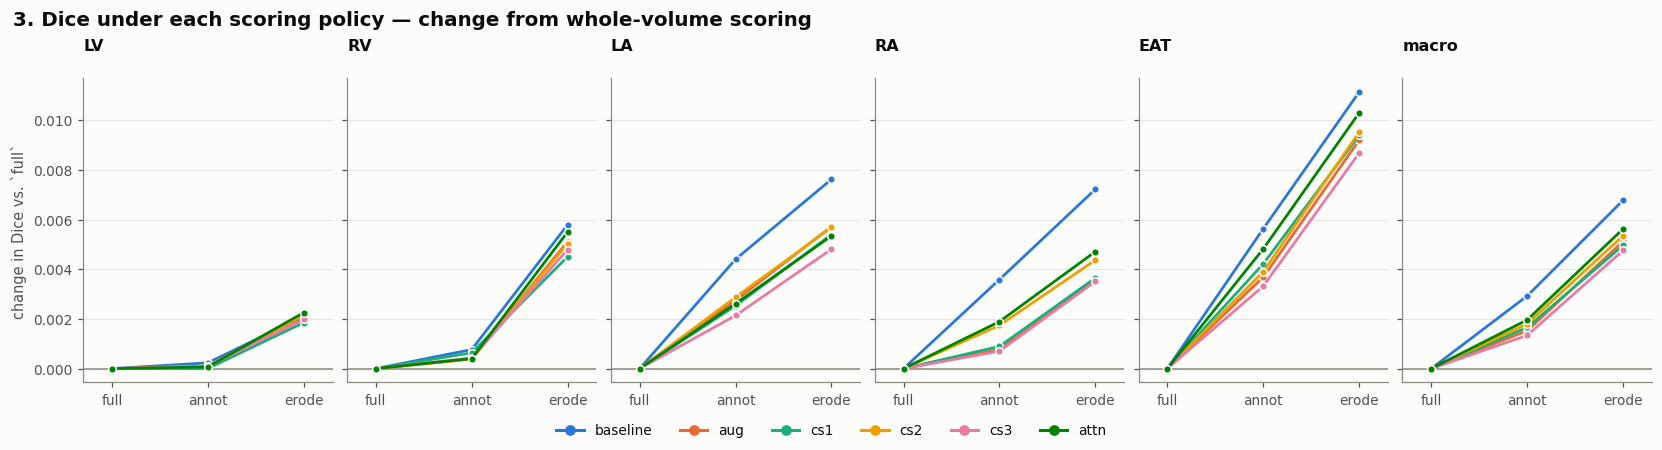

In [6]:
# Plotted as the CHANGE from `full`, on one shared axis across all six panels.
# Per-panel autoscaling of the raw Dice would make a +0.002 shift on LV look identical
# to a +0.007 shift on RA -- the whole point here is which structures actually move.
# NB: constrained layout, and no axes-anchored caption -- a text box that wide
# anchored to an axes makes the layout engine collapse the axes to nothing.
SHORT = ['full', 'annot', 'erode']
x = np.arange(len(VARIANTS))

fig, axes = plt.subplots(1, len(CLASSES), figsize=(15, 4.0), sharey=True, layout='constrained')
for ax, cls in zip(axes, CLASSES):
    for arm in ARMS:
        base = np.nanmean(vals(arm, 'full', cls))
        y = [np.nanmean(vals(arm, v, cls)) - base for v in VARIANTS]
        ax.plot(x, y, color=ARM_COLOR[arm], linewidth=1.8, marker='o', markersize=5,
                markeredgecolor=SURFACE, markeredgewidth=1.0, zorder=3)
    ax.axhline(0, color=INK_MUTED, linewidth=1.0, zorder=1)
    ax.set_xticks(x, SHORT)
    ax.set_xlim(-0.3, len(VARIANTS) - 0.7)
    ax.set_title('macro' if cls.startswith('all') else cls)
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('change in Dice vs. `full`')
fig.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=2, marker='o', markersize=6, label=a)
                    for a in ARMS],
           loc='outside lower center', ncol=len(ARMS), frameon=False)
fig.suptitle('3. Dice under each scoring policy — change from whole-volume scoring',
             x=0.004, ha='left', fontsize=13, fontweight='semibold')
plt.show()

## 4. Effect on the distance metrics

Dice is bounded and dilutes a localised error across the whole volume. HD95 and ASSD do
not: they are driven by the *worst* surface disagreement, and a confident prediction
fifteen slices beyond the labelled extent is enormously far from any ground-truth surface
voxel. So the distance metrics should be hit harder than Dice — and because HD95 is the
metric most often quoted against published numbers, that matters for reporting.

Same encoding as §3: the **change** from whole-volume scoring, one line per arm, on a
shared scale within each row. Negative means the policy removed error.

In [7]:
table('hd95_mm'); print(); table('assd_mm')

--- hd95_mm : mean over 42 patients ---
                     LV                        RV                        LA                        RA                       EAT                      macro            
arm           full   annot   erode      full   annot   erode      full   annot   erode      full   annot   erode      full   annot   erode      full   annot   erode  
baseline    6.5688  6.4856  5.7668    6.9543  6.9115  6.5163    7.9738  7.4896  7.1164    8.3816  4.8518  4.4042    5.4689  4.9499  4.7504    7.0695  6.1377  5.7108  
aug         4.2244  4.2181  4.0153    5.0306  5.0221  4.7903    4.4228  4.1863  3.9604    3.8920  3.6691  3.4409    4.6711  4.4995  4.3217    4.4482  4.3190  4.1057  
cs1         4.0804  4.0804  3.8900    4.0730  4.0720  3.8737    7.0560  6.7721  6.5148    3.5658  3.4843  3.2755    4.8468  4.4813  4.2751    4.7244  4.5780  4.3658  
cs2         4.1928  4.1840  3.9993    5.2906  5.2909  5.0433    4.6481  4.3988  4.0946    3.7697  3.5166  3.3382    4.9782  4

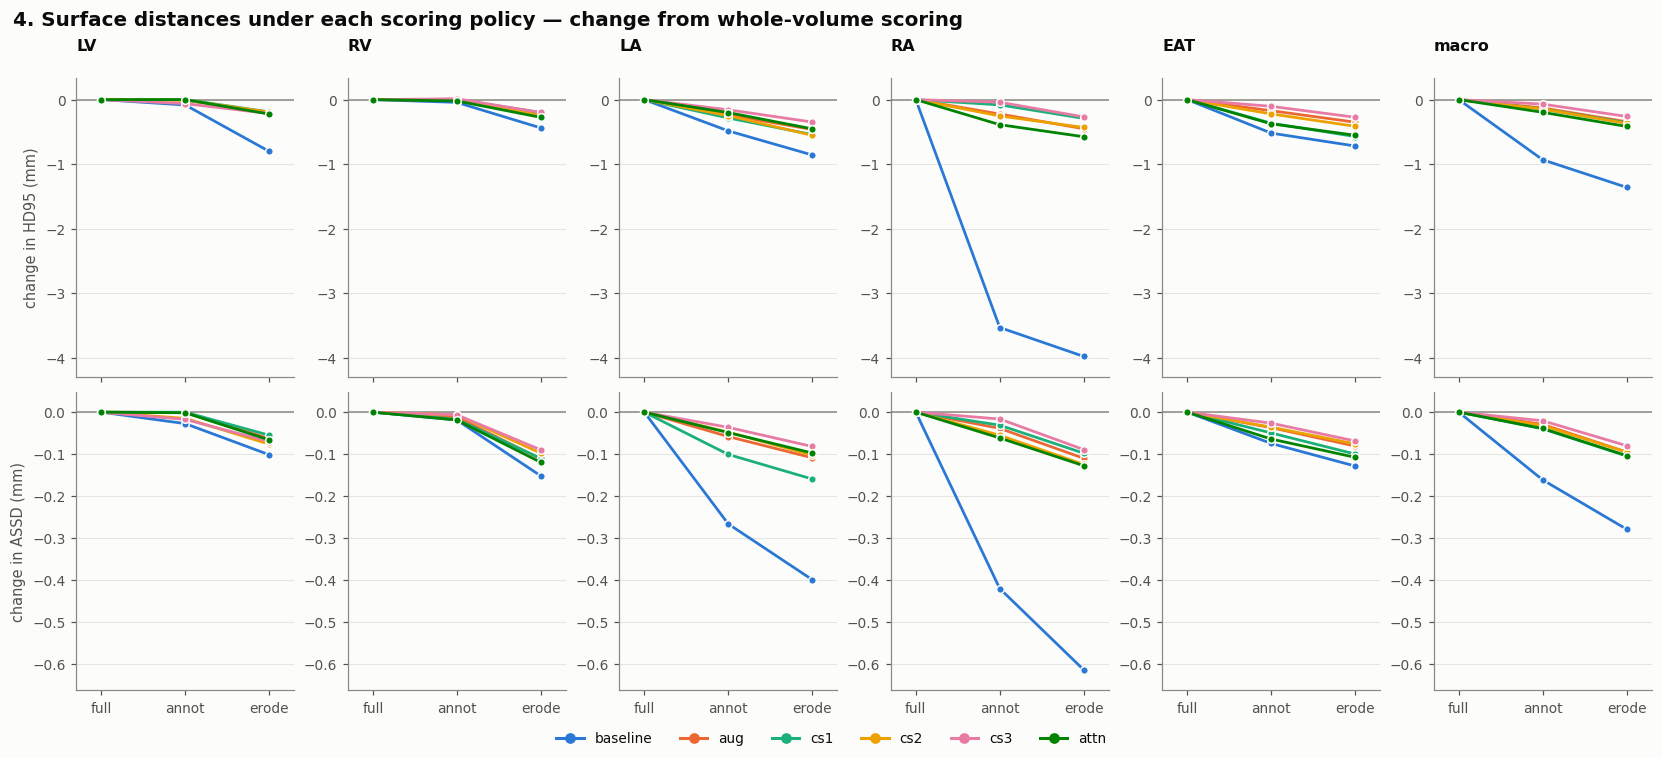

In [8]:
x = np.arange(len(VARIANTS))
fig, axes = plt.subplots(2, len(CLASSES), figsize=(15, 6.8), sharex=True, layout='constrained')
for row, metric, unit in ((0, 'hd95_mm', 'change in HD95 (mm)'), (1, 'assd_mm', 'change in ASSD (mm)')):
    lo, hi = 0.0, 0.0
    for ax, cls in zip(axes[row], CLASSES):
        for arm in ARMS:
            base = np.nanmean(vals(arm, 'full', cls, metric))
            y = [np.nanmean(vals(arm, v, cls, metric)) - base for v in VARIANTS]
            lo, hi = min(lo, min(y)), max(hi, max(y))
            ax.plot(x, y, color=ARM_COLOR[arm], linewidth=1.8, marker='o', markersize=5,
                    markeredgecolor=SURFACE, markeredgewidth=1.0, zorder=3)
        ax.axhline(0, color=INK_MUTED, linewidth=1.0, zorder=1)
        ax.set_xticks(x, SHORT)
        ax.set_xlim(-0.3, len(VARIANTS) - 0.7)
        ax.grid(axis='x', visible=False)
        if row == 0:
            ax.set_title('macro' if cls.startswith('all') else cls)
    for ax in axes[row]:                      # one shared scale per metric row
        ax.set_ylim(lo - 0.08 * (hi - lo), hi + 0.08 * (hi - lo))
    axes[row][0].set_ylabel(unit)
fig.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=2, marker='o', markersize=6, label=a)
                    for a in ARMS],
           loc='outside lower center', ncol=len(ARMS), frameon=False)
fig.suptitle('4. Surface distances under each scoring policy — change from whole-volume scoring',
             x=0.004, ha='left', fontsize=13, fontweight='semibold')
plt.show()

## 5. The actual question — do the conclusions move?

Sections 3 and 4 are about absolute numbers. This section is the sensitivity analysis
proper: **every conclusion we have drawn from these runs is a paired difference between
two arms**, so what matters is whether those differences survive the change of policy.

Three contrasts, each paired patient-by-patient:

| contrast | what it tests |
|---|---|
| `aug → cs3` | 2.5D context, the single clean factor (both arms have `augment=True`) |
| `baseline → aug` | augmentation, the single clean factor |
| `baseline → cs3` | **confounded** — differs in *both* factors; the comparison the original diagnostic notebook made |

Tested on **all three metrics**, because §3 and §4 showed they are affected very
differently — a conclusion can be robust in Dice and fragile in HD95.

> **On the two intervals reported.** The table gives a mean with a t-based 95% CI *and* a
> median with a Wilcoxon p. For Dice these agree. For HD95 they can diverge sharply,
> because paired HD95 differences are heavily skewed by a few patients with large surface
> errors: the parametric CI is dragged wide by those outliers while the rank test stays
> decisive. **Where they disagree, trust the rank test** — which is why the figure plots
> the *median* difference with a bootstrap CI, matching the test actually being run.

In the figure the dot is the **median** paired difference and the bar its bootstrap
95% CI; a CI spanning zero is a null result.

Following this repo's convention these p-values are **descriptive**: the per-chamber
family would need Holm correction and at this n cannot survive it.

In [9]:
CONTRASTS = [('aug', 'cs3', 'context'), ('baseline', 'aug', 'augmentation'),
             ('baseline', 'cs3', 'confounded')]
METRICS = [('dice', 'Dice', '{:>+9.4f}'), ('hd95_mm', 'HD95 (mm)', '{:>+9.3f}'),
           ('assd_mm', 'ASSD (mm)', '{:>+9.3f}')]

def boot_ci(d, n_boot=5000, seed=0):
    """Percentile bootstrap CI for the MEDIAN paired difference.

    Paired HD95 differences are strongly skewed, so a t-interval on the mean is a poor
    summary; the median is what the Wilcoxon test is really about.
    """
    rng = np.random.default_rng(seed)
    s = np.median(d[rng.integers(0, len(d), size=(n_boot, len(d)))], axis=1)
    return float(np.percentile(s, 2.5)), float(np.percentile(s, 97.5))

def paired(a, b, variant, cls, metric='dice'):
    x, y = vals(a, variant, cls, metric), vals(b, variant, cls, metric)
    ok = ~(np.isnan(x) | np.isnan(y))
    d = y[ok] - x[ok]
    hw = student_t.ppf(0.975, len(d) - 1) * d.std(ddof=1) / np.sqrt(len(d))
    mlo, mhi = boot_ci(d)
    return dict(mean=d.mean(), lo=d.mean() - hw, hi=d.mean() + hw,
                median=float(np.median(d)), mlo=mlo, mhi=mhi,
                p=wilcoxon(y[ok], x[ok]).pvalue, n=len(d), win=int((d > 0).sum()))

for metric, mlabel, fmt in METRICS:
    for cls in (EAT, 'all_classes_macro'):
        name_cls = 'macro' if cls.startswith('all') else cls
        print(f'=== {name_cls} : {mlabel}, paired differences (n={len(PATIENTS)}) ===')
        print(f'{"contrast":<32}{"policy":<11}{"mean":>9}{"95% CI (mean)":>22}'
              f'{"median":>9}{"95% CI (median)":>22}{"p":>9}')
        for a, b, cname in CONTRASTS:
            for v in VARIANTS:
                r = paired(a, b, v, cls, metric)
                label = '{} -> {}  ({})'.format(a, b, cname)
                ci = '[{:+.3f}, {:+.3f}]'.format(r['lo'], r['hi'])
                mci = '[{:+.3f}, {:+.3f}]'.format(r['mlo'], r['mhi'])
                print(f'{label:<32}{v:<11}' + fmt.format(r['mean']) +
                      f'{ci:>22}' + fmt.format(r['median']) + f'{mci:>22}{r["p"]:>9.4f}')
        print()

=== EAT : Dice, paired differences (n=42) ===
contrast                        policy          mean         95% CI (mean)   median       95% CI (median)        p
aug -> cs3  (context)           full         -0.0004      [-0.005, +0.004]  -0.0015      [-0.006, +0.003]   0.5439
aug -> cs3  (context)           annotated    -0.0008      [-0.005, +0.003]  -0.0004      [-0.007, +0.002]   0.5114
aug -> cs3  (context)           eroded       -0.0009      [-0.005, +0.003]  +0.0009      [-0.006, +0.002]   0.5944
baseline -> aug  (augmentation) full         +0.0136      [+0.007, +0.020]  +0.0095      [+0.004, +0.017]   0.0001
baseline -> aug  (augmentation) annotated    +0.0117      [+0.006, +0.017]  +0.0103      [+0.003, +0.016]   0.0001
baseline -> aug  (augmentation) eroded       +0.0117      [+0.006, +0.018]  +0.0097      [+0.003, +0.017]   0.0001
baseline -> cs3  (confounded)   full         +0.0132      [+0.007, +0.020]  +0.0100      [+0.001, +0.016]   0.0002
baseline -> cs3  (confounded)   an

aug -> cs3  (context)           annotated     +0.055      [-0.250, +0.360]   -0.166      [-0.243, +0.051]   0.7756
aug -> cs3  (context)           eroded        +0.063      [-0.275, +0.401]   -0.034      [-0.351, +0.092]   0.9311
baseline -> aug  (augmentation) full          -0.798      [-1.444, -0.152]   -0.322      [-0.637, +0.114]   0.0546
baseline -> aug  (augmentation) annotated     -0.450      [-0.849, -0.052]   -0.242      [-0.602, +0.028]   0.0431
baseline -> aug  (augmentation) eroded        -0.429      [-0.840, -0.017]   -0.031      [-0.300, +0.073]   0.1393
baseline -> cs3  (confounded)   full          -0.811      [-1.497, -0.125]   -0.131      [-0.561, +0.049]   0.0445
baseline -> cs3  (confounded)   annotated     -0.396      [-0.779, -0.013]   -0.142      [-0.458, +0.049]   0.0983
baseline -> cs3  (confounded)   eroded        -0.366      [-0.740, +0.009]   -0.087      [-0.429, +0.000]   0.1065

=== macro : HD95 (mm), paired differences (n=42) ===
contrast                  

baseline -> aug  (augmentation) eroded        -0.099      [-0.178, -0.020]   -0.044      [-0.075, -0.003]   0.0285
baseline -> cs3  (confounded)   full          -0.147      [-0.257, -0.037]   -0.043      [-0.076, +0.007]   0.0203
baseline -> cs3  (confounded)   annotated     -0.099      [-0.179, -0.019]   -0.028      [-0.076, +0.012]   0.0433
baseline -> cs3  (confounded)   eroded        -0.087      [-0.161, -0.014]   -0.028      [-0.083, +0.005]   0.0620

=== macro : ASSD (mm), paired differences (n=42) ===
contrast                        policy          mean         95% CI (mean)   median       95% CI (median)        p
aug -> cs3  (context)           full          +0.015      [-0.067, +0.098]   -0.008      [-0.032, +0.013]   0.4131
aug -> cs3  (context)           annotated     +0.024      [-0.061, +0.109]   -0.013      [-0.029, +0.013]   0.4203
aug -> cs3  (context)           eroded        +0.030      [-0.057, +0.118]   -0.012      [-0.029, +0.013]   0.5689
baseline -> aug  (augmenta

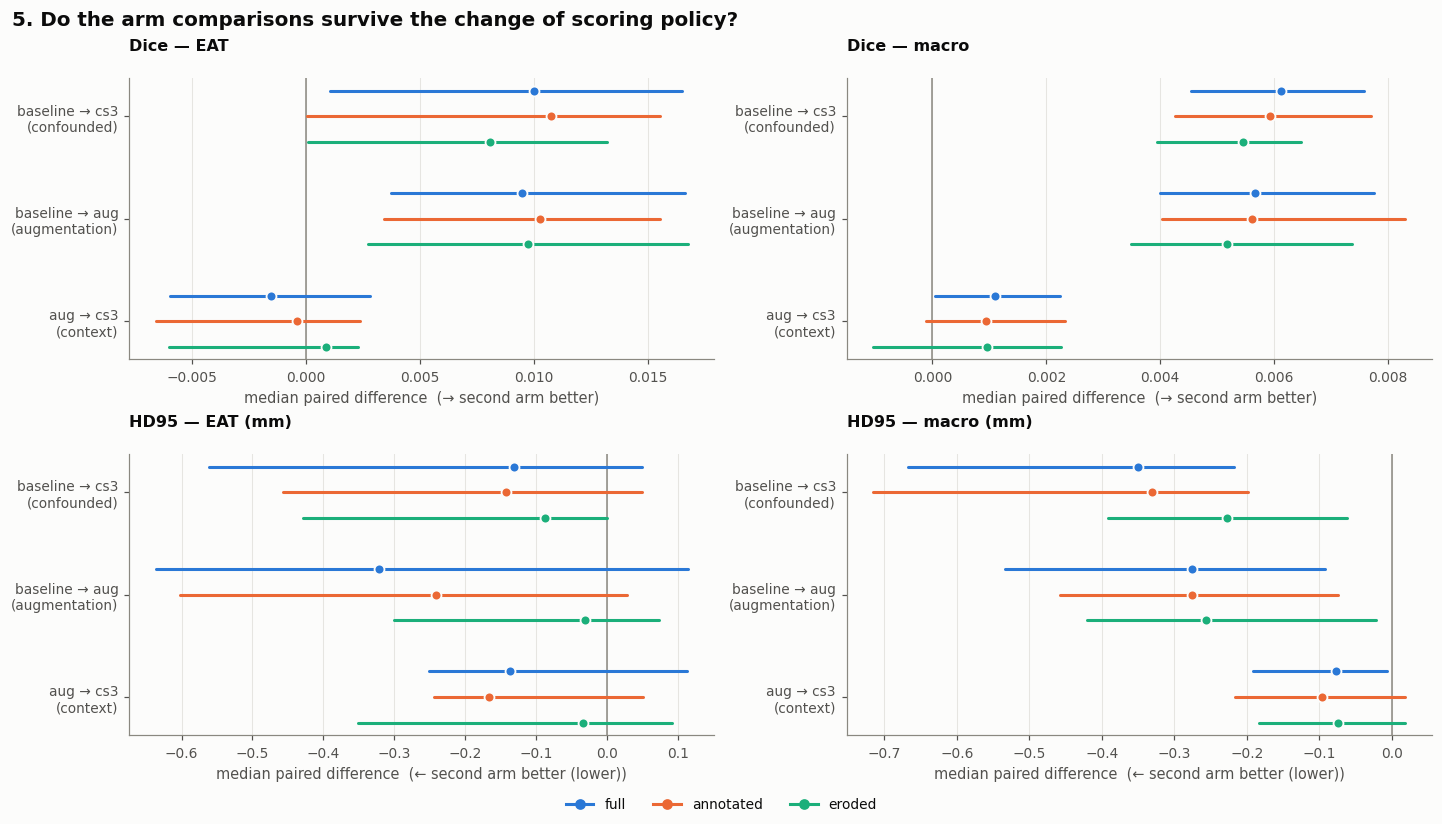

In [10]:
PANELS = [('dice', EAT, 'Dice — EAT'), ('dice', 'all_classes_macro', 'Dice — macro'),
          ('hd95_mm', EAT, 'HD95 — EAT (mm)'), ('hd95_mm', 'all_classes_macro', 'HD95 — macro (mm)')]

fig, axes = plt.subplots(2, 2, figsize=(13, 7.4), layout='constrained')
for ax, (metric, cls, title) in zip(axes.ravel(), PANELS):
    ypos, labels = [], []
    for i, (a, b, cname) in enumerate(CONTRASTS):
        for j, v in enumerate(VARIANTS):
            r = paired(a, b, v, cls, metric)
            y = i * (len(VARIANTS) + 1) + (len(VARIANTS) - 1 - j)
            ax.plot([r['mlo'], r['mhi']], [y, y], color=VARIANT_COLOR[v], linewidth=2.0,
                    solid_capstyle='round', zorder=2)
            ax.scatter([r['median']], [y], s=42, color=VARIANT_COLOR[v],
                       edgecolor=SURFACE, linewidth=1.2, zorder=3)
            if j == len(VARIANTS) - 1:
                ypos.append(i * (len(VARIANTS) + 1) + 1)
                labels.append(f'{a} → {b}\n({cname})')
    ax.axvline(0, color=INK_MUTED, linewidth=1.0, zorder=1)
    ax.set_yticks(ypos, labels)
    ax.grid(axis='y', visible=False)
    ax.set_title(title)
    better = 'second arm better' if metric == 'dice' else 'second arm better (lower)'
    ax.set_xlabel(f'median paired difference  ({"→ " if metric == "dice" else "← "}{better})')
fig.legend(handles=[Line2D([], [], color=VARIANT_COLOR[v], lw=2, marker='o',
                           markersize=6, label=v) for v in VARIANTS],
           loc='outside lower center', ncol=len(VARIANTS), frameon=False)
fig.suptitle('5. Do the arm comparisons survive the change of scoring policy?',
             x=0.004, ha='left', fontsize=13, fontweight='semibold')
plt.show()

## 6. Robustness — does the answer depend on where the boundary is drawn?

`annotated` keeps every labelled slice; `eroded` throws away three more at each end, on
the grounds that the outermost labelled slice is often only partly drawn. If the two
disagree, the result is sensitive to a judgement call and should be reported as such.

> **`eroded` is a robustness probe, not a better estimate of performance.** Unlike
> `annotated`, it discards slices that *do* carry valid ground truth — and it discards the
> hardest ones, the thin tapering ends of each structure. Its absolute scores are
> therefore optimistically biased and must not be quoted as the model's accuracy. Only its
> *contrasts* are meaningful here, because the same slices are dropped for both arms in
> every pair.

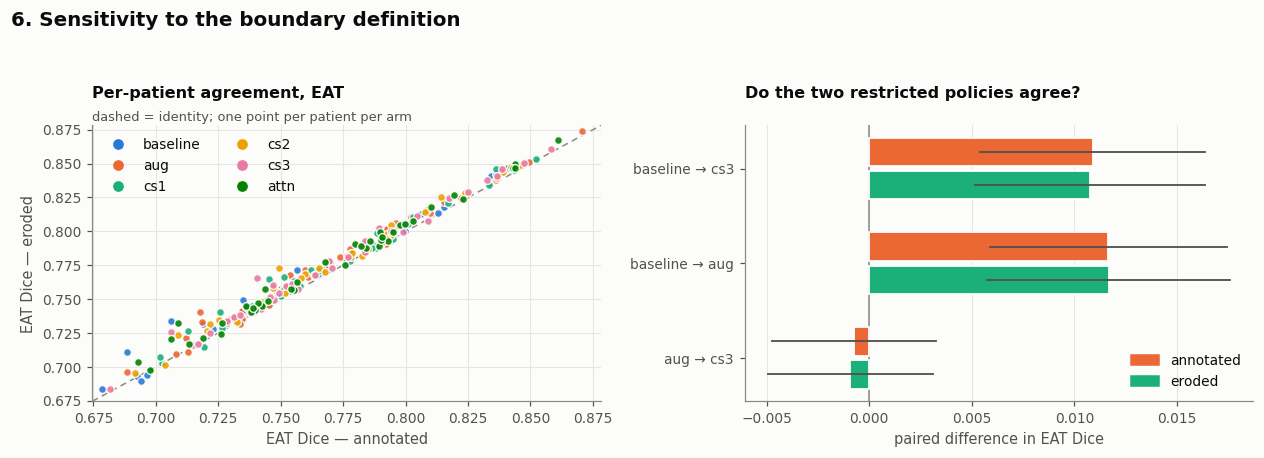

contrast                 annotated    eroded   difference
aug -> cs3                 -0.0008   -0.0009      -0.0002
baseline -> aug            +0.0117   +0.0117      +0.0000
baseline -> cs3            +0.0109   +0.0107      -0.0001


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

ax = axes[0]
lims = [1, 0]
for arm in ARMS:
    xa, ya = vals(arm, 'annotated', EAT), vals(arm, 'eroded', EAT)
    ax.scatter(xa, ya, s=26, color=ARM_COLOR[arm], edgecolor=SURFACE, linewidth=0.9,
               alpha=0.9, zorder=3)
    lims = [min(lims[0], np.nanmin(xa), np.nanmin(ya)), max(lims[1], np.nanmax(xa), np.nanmax(ya))]
pad = 0.02 * (lims[1] - lims[0])
ax.plot([lims[0] - pad, lims[1] + pad], [lims[0] - pad, lims[1] + pad],
        color=INK_MUTED, linewidth=1.0, linestyle=(0, (4, 3)), zorder=1)
ax.set_xlim(lims[0] - pad, lims[1] + pad); ax.set_ylim(lims[0] - pad, lims[1] + pad)
ax.set_xlabel('EAT Dice — annotated'); ax.set_ylabel('EAT Dice — eroded')
ax.set_title('Per-patient agreement, EAT')
subtitle(ax, 'dashed = identity; one point per patient per arm')
ax.legend(handles=[Line2D([], [], color=ARM_COLOR[a], lw=0, marker='o', markersize=6, label=a)
                   for a in ARMS], loc='upper left', ncol=2)

ax = axes[1]
w = 0.35
for i, (a, b, name) in enumerate(CONTRASTS):
    for j, v in enumerate(('annotated', 'eroded')):
        r = paired(a, b, v, EAT)
        ax.barh(i + (0.5 - j) * w, r['mean'], height=w * 0.86, color=VARIANT_COLOR[v],
                edgecolor=SURFACE, linewidth=1.2, zorder=3)
        ax.plot([r['lo'], r['hi']], [i + (0.5 - j) * w] * 2, color=INK_2, linewidth=1.2, zorder=4)
ax.axvline(0, color=INK_MUTED, linewidth=1.0, zorder=1)
ax.set_yticks(range(len(CONTRASTS)), [f'{a} → {b}' for a, b, _ in CONTRASTS])
ax.grid(axis='y', visible=False)
ax.set_xlabel('paired difference in EAT Dice')
ax.set_title('Do the two restricted policies agree?')
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=VARIANT_COLOR[v], label=v)
                   for v in ('annotated', 'eroded')], loc='best')

fig.suptitle('6. Sensitivity to the boundary definition', x=0.005, ha='left',
             fontsize=13, fontweight='semibold')
fig.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

print(f'{"contrast":<22}{"annotated":>12}{"eroded":>10}{"difference":>13}')
for a, b, name in CONTRASTS:
    ra, re = paired(a, b, 'annotated', EAT), paired(a, b, 'eroded', EAT)
    print(f'{f"{a} -> {b}":<22}{ra["mean"]:>+12.4f}{re["mean"]:>+10.4f}{re["mean"] - ra["mean"]:>+13.4f}')

## 7. Verdict

**The truncation depressed every absolute score and inflated some effect sizes, but it did
not overturn a single Dice conclusion.** Three conclusions do move — all of them EAT
*distance* metrics, and all of them results that were never solid to begin with.

The check below applies one rule to every conclusion these runs support: a conclusion is
its **direction** plus whether it is **distinguishable from zero**, and both must survive
the change of policy for it to count as robust.

### What the analysis found

**1. The defect is universal but mostly mild.** 49/50 volumes have unannotated slices;
16.6% of slices per volume on average, and 17/50 lose more than 20%. Severity is the
part that matters: labelling stops with >30% of peak foreground still present in **26/50**
volumes at the bottom end and 4/50 at the top. So the bottom end — not the top, which is
where the `CADRE_1851` case study drew attention — is the more common offender.

**2. Dice barely moves.** Discarding 638 slices that carry no ground truth at all buys back
only ~0.005 EAT Dice (baseline 0.7544 → 0.7600; best arm 0.7680 → 0.7717) and ~0.002 macro.
Dice's denominator is dominated by the correctly segmented bulk of the heart, so a
localised block of false positives is diluted.

**3. The distance metrics move a lot, and — critically — *unevenly across arms*.**
Macro HD95 falls 7.07 → 6.14 mm for `baseline` but only 4.45 → 4.32 mm for `aug`; RA HD95
for `baseline` falls 8.38 → 4.85 mm while no other arm moves more than 0.6 mm. The
truncation penalty was concentrated almost entirely in the *worst* arm. That is exactly the
non-uniform distortion that biases a comparison rather than merely offsetting it.

**4. Every Dice conclusion is robust.** Context is null under all three policies
(EAT p = 0.51–0.59, macro p = 0.06–0.12); augmentation is significant under all three
(p ≤ 0.0001), with the effect shrinking modestly from +0.0136 to +0.0117 — about 14%
of the apparent gain was truncation.

**5. Three conclusions move, all EAT distance metrics:**

| conclusion | `full` | `annotated` | `eroded` |
|---|---|---|---|
| HD95 EAT `baseline → aug` | null (p=0.055) | better (p=0.043) | null (p=0.139) |
| HD95 EAT `baseline → cs3` | better (p=0.044) | null (p=0.098) | null (p=0.106) |
| ASSD EAT `baseline → cs3` | better (p=0.020) | better (p=0.043) | null (p=0.062) |

No direction ever flips — every one of these is a p-value wandering across 0.05. The right
reading is **not** "the truncation destroyed these findings" but "these findings were
fragile at n=42 and should never have been leaned on". A result that changes verdict
because 16% of slices were dropped is a result at the edge of what this sample can resolve.

**6. The answer does not depend on where the boundary is drawn.** `annotated` and `eroded`
agree on every Dice contrast to within 0.0003, despite `eroded` discarding a further 252
slices.

### What to do with this

- **Report EAT Dice under `annotated`** as the headline segmentation number, noting that
  the whole-volume figure is conservative. The difference is small enough that nothing
  already written needs retracting.
- **Report HD95 and ASSD under `annotated`.** Whole-volume scoring overstates arm
  differences on these metrics by up to ~30%, and does so unevenly, so it is the wrong
  basis for comparing arms — and HD95 is the number most often quoted against published
  work.
- **Never quote `eroded` absolute values** — it discards valid, hard boundary slices and is
  optimistically biased. It is a robustness probe only.
- **Do not report EAT HD95/ASSD arm differences as established.** They are not stable.
- The project's Dice-based conclusions — augmentation helps, context does not — **stand as
  written**.

### What this does not address

This is a re-scoring. The *training-side* question — that the model is currently trained to
predict background on slices where the heart is plainly visible, which may well be driving
the under-segmentation seen at the inferior end — is untouched and remains open. Masking
unannotated slices out of the loss would be a separate experiment requiring retraining.

In [12]:
# --- the decision rule, applied to every conclusion these runs support -------
# A conclusion is its DIRECTION plus whether it is distinguishable from zero.
# Both must survive the change of policy for the conclusion to be called robust.
def reading(r, metric):
    if r['p'] >= 0.05:
        return 'null'
    better = (r['median'] > 0) if metric == 'dice' else (r['median'] < 0)
    return 'better' if better else 'worse'

print(f'{"metric":<11}{"class":<8}{"contrast":<28}'
      + ''.join(f'{v:>22}' for v in VARIANTS) + '   verdict')
moved, effect_shrink = [], []
for metric, mlabel, fmt in METRICS:
    for cls in (EAT, 'all_classes_macro'):
        cname_ = 'macro' if cls.startswith('all') else cls
        for a, b, cname in CONTRASTS:
            rs = {v: paired(a, b, v, cls, metric) for v in VARIANTS}
            reads = {v: reading(rs[v], metric) for v in VARIANTS}
            stable = len(set(reads.values())) == 1
            cells_ = ''.join('{:>22}'.format('{} (p={:.3f})'.format(reads[v], rs[v]['p']))
                             for v in VARIANTS)
            con_ = '{}->{}'.format(a, b)
            print(f'{mlabel:<11}{cname_:<8}{con_:<28}{cells_}   '
                  + ('stable' if stable else '*** MOVED ***'))
            if not stable:
                moved.append((mlabel, cname_, f'{a}->{b}', reads))
            if reads['full'] != 'null' and abs(rs['full']['median']) > 0:
                effect_shrink.append((mlabel, cname_, f'{a}->{b}',
                                      1 - abs(rs['annotated']['median']) / abs(rs['full']['median'])))
    print()

print('=' * 100)
if moved:
    print(f'\n{len(moved)} conclusion(s) change when the unannotated slices are excluded:\n')
    for mlabel, cls, con, reads in moved:
        print(f'  {mlabel:<11}{cls:<8}{con:<24}' + '  '.join(f'{v}={reads[v]}' for v in VARIANTS))
else:
    print('\nNo conclusion changes direction or nullity under any policy.')

print('\nEffect-size inflation attributable to the truncation')
print('(how much the effect shrinks going from `full` to `annotated`):\n')
for mlabel, cls, con, shrink in sorted(effect_shrink, key=lambda r: -r[3])[:6]:
    print(f'  {mlabel:<11}{cls:<8}{con:<24}{shrink:>7.0%} smaller')

metric     class   contrast                                      full             annotated                eroded   verdict
Dice       EAT     aug->cs3                            null (p=0.544)        null (p=0.511)        null (p=0.594)   stable
Dice       EAT     baseline->aug                     better (p=0.000)      better (p=0.000)      better (p=0.000)   stable
Dice       EAT     baseline->cs3                     better (p=0.000)      better (p=0.000)      better (p=0.001)   stable
Dice       macro   aug->cs3                            null (p=0.062)        null (p=0.070)        null (p=0.122)   stable


Dice       macro   baseline->aug                     better (p=0.000)      better (p=0.000)      better (p=0.000)   stable
Dice       macro   baseline->cs3                     better (p=0.000)      better (p=0.000)      better (p=0.000)   stable

HD95 (mm)  EAT     aug->cs3                            null (p=0.523)        null (p=0.776)        null (p=0.931)   stable


HD95 (mm)  EAT     baseline->aug                       null (p=0.055)      better (p=0.043)        null (p=0.139)   *** MOVED ***
HD95 (mm)  EAT     baseline->cs3                     better (p=0.044)        null (p=0.098)        null (p=0.106)   *** MOVED ***
HD95 (mm)  macro   aug->cs3                            null (p=0.152)        null (p=0.092)        null (p=0.223)   stable
HD95 (mm)  macro   baseline->aug                     better (p=0.001)      better (p=0.001)      better (p=0.001)   stable
HD95 (mm)  macro   baseline->cs3                     better (p=0.000)      better (p=0.000)      better (p=0.001)   stable



ASSD (mm)  EAT     aug->cs3                            null (p=0.560)        null (p=0.720)        null (p=0.921)   stable
ASSD (mm)  EAT     baseline->aug                     better (p=0.018)      better (p=0.018)      better (p=0.029)   stable
ASSD (mm)  EAT     baseline->cs3                     better (p=0.020)      better (p=0.043)        null (p=0.062)   *** MOVED ***


ASSD (mm)  macro   aug->cs3                            null (p=0.413)        null (p=0.420)        null (p=0.569)   stable
ASSD (mm)  macro   baseline->aug                     better (p=0.000)      better (p=0.000)      better (p=0.000)   stable
ASSD (mm)  macro   baseline->cs3                     better (p=0.000)      better (p=0.000)      better (p=0.000)   stable


3 conclusion(s) change when the unannotated slices are excluded:

  HD95 (mm)  EAT     baseline->aug           full=null  annotated=better  eroded=null
  HD95 (mm)  EAT     baseline->cs3           full=better  annotated=null  eroded=null
  ASSD (mm)  EAT     baseline->cs3           full=better  annotated=better  eroded=null

Effect-size inflation attributable to the truncation
(how much the effect shrinks going from `full` to `annotated`):

  ASSD (mm)  EAT     baseline->cs3               34% smaller
  ASSD (mm)  EAT     baseline->aug                7% smaller
  HD95 (mm)  macro   baseline->cs3                6% smaller
 